In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sleppyfish/aircraft-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'aircraft-classification-dataset' dataset.
Path to dataset files: /kaggle/input/aircraft-classification-dataset
Contents of base_path (/kaggle/input):
['aircraft-classification-dataset']
Contents of path (/kaggle/input/aircraft-classification-dataset):
['test', 'train']


### Dataset Overview

Let's examine the structure of the downloaded dataset and display some sample images from the `train` and `test` directories.

In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'test'))}")

Contents of the 'train' directory: ['7', '2', '5', '8', '3', '1', '4', '9', '6']
Contents of the 'test' directory: ['7', '2', '5', '8', '3', '1', '4', '9', '6']


### Displaying Sample Images

Now, let's visualize a few sample images from the 'train' and 'test' datasets to get a better understanding of the image content.


--- Sample Images from Training Dataset (/kaggle/input/aircraft-classification-dataset/train) ---
Found 19569 images in /kaggle/input/aircraft-classification-dataset/train. Displaying 6 samples:


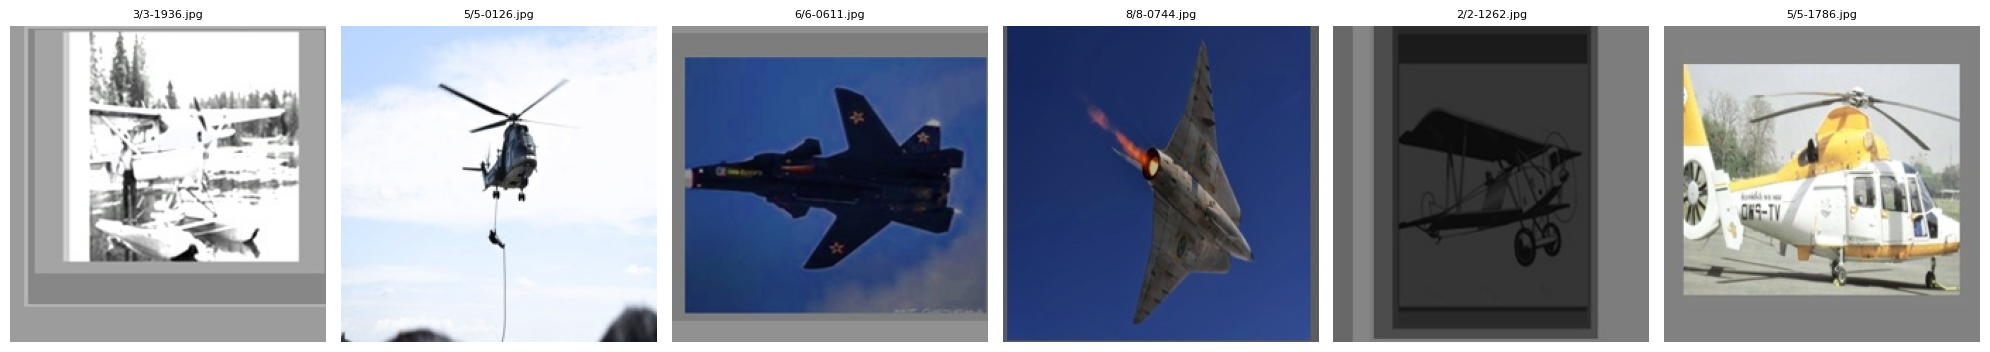


--- Sample Images from Test Dataset (/kaggle/input/aircraft-classification-dataset/test) ---
Found 2305 images in /kaggle/input/aircraft-classification-dataset/test. Displaying 6 samples:


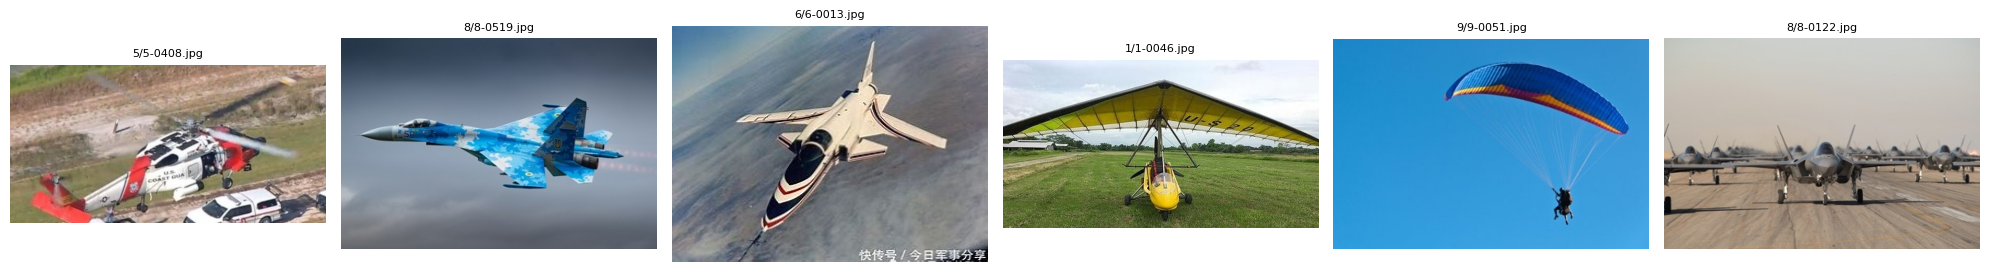

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig) # Close empty figure if no samples
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Display sample images from the 'train' directory
train_path = os.path.join(path, 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

# Display sample images from the 'test' directory
test_path = os.path.join(path, 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Setting memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("GPU is NOT available. Using CPU instead.")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 9

# Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Build Model based on VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Found 15657 images belonging to 9 classes.
Found 3912 images belonging to 9 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting training...
Epoch 1/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 360s 702ms/step - accuracy: 0.4996 - loss: 1.4035 - val_accuracy: 0.5677 - val_loss: 1.3120
Epoch 2/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 274s 560ms/step - accuracy: 0.6357 - loss: 1.0426 - val_accuracy: 0.6690 - val_loss: 0.9913
Epoch 3/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 275s 562ms/step - accuracy: 0.6834 - loss: 0.9121 - val_accuracy: 0.7449 - val_loss: 0.7657
Epoch 4/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 271s 553ms/step - accuracy: 0.7051 - loss: 0.8462 - val_accuracy: 0.7193 - val_loss: 0.8220
Epoch 5/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 272s 555ms/step - accuracy: 0.7304 - loss: 0.7897 - val_accuracy: 0.7462 - val_loss: 0.7589
Epoch 6/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 272s 555ms/step - accuracy: 0.7374 - loss: 0.7580 - val_accuracy: 0.7830 - val_loss: 0.6388
Epoch 7/10
490/490 ━━━━━━━━━━━━━━━━━━━━ 271s 554ms/

In [ ]:
# Evaluation on Test Set
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

results = model.evaluate(test_generator)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

# Summary of model performance
print("\n--- Model Summary ---")
model.summary()

Found 2305 images belonging to 9 classes.
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 187ms/step - accuracy: 0.8803 - loss: 0.3875
Test Loss: 0.3875
Test Accuracy: 0.8803

--- Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,989,981 (129.66 MB)

 Trainable params: 6,425,097 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 12,850,196 (49.02 MB)

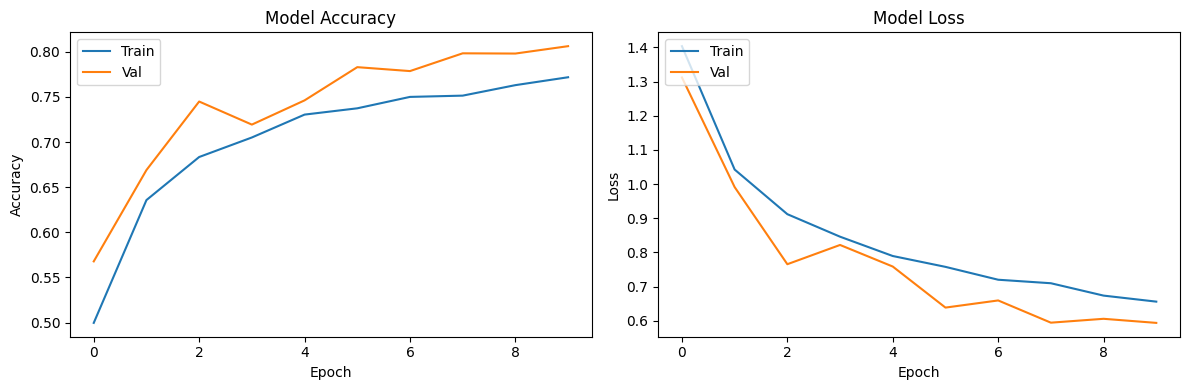

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()